In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d devang03mgr/cattle-diseases-datasets

Dataset URL: https://www.kaggle.com/datasets/devang03mgr/cattle-diseases-datasets
License(s): DbCL-1.0
100% 257M/257M [00:04<00:00, 60.4MB/s]



In [ ]:
import zipfile
import os
zip_file = "cattle-diseases-datasets.zip"
with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("/content")
print(os.listdir("/content"))

['.config', 'cattle-diseases-datasets.zip', 'Cows datasets', 'kaggle.json', 'sample_data']


In [ ]:
import os
os.listdir()

['.config',
 'cattle-diseases-datasets.zip',
 'Cows datasets',
 'kaggle.json',
 'sample_data']

In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    print(root)
    for directory in dirs:
        print(" ",directory)

/content
  .config
  Cows datasets
  sample_data
/content/.config
  configurations
  logs
/content/.config/configurations
/content/.config/logs
  2026.08.24
/content/.config/logs/2026.08.24
/content/Cows datasets
  lumpy
  foot-and-mouth
  healthy
/content/Cows datasets/lumpy
/content/Cows datasets/foot-and-mouth
/content/Cows datasets/healthy
/content/sample_data


In [ ]:
import os
DATA_DIR = "/content/Cows datasets"

if not os.path.exists(DATA_DIR):
  raise FileNotFoundError(
      f"Dataset folder not found: {DATA_DIR}"
  )
EXPECTED_CLASSES=["healthy","lumpy","foot-and-mouth"]
for class_names in EXPECTED_CLASSES:
  class_path=os.path.join(DATA_DIR,class_names)
  if not os.path.exists(class_path):
    raise FileNotFoundError(
        f"Class folder not found: {class_path}"
    )
print("Dataset path verified successfully!")

print("\nDataset directory:")
print(DATA_DIR)

print("\nDisease classes found:")

for class_name in EXPECTED_CLASSES:
  class_path=os.path.join(DATA_DIR,class_name)
  nof=len(os.listdir(class_path))
  print(f"{class_name}:{nof} files")



Dataset path verified successfully!

Dataset directory:
/content/Cows datasets

Disease classes found:
healthy:1291 files
lumpy:1207 files
foot-and-mouth:746 files


## **VERIFY IMAGE FILES**

In [ ]:
from PIL import Image
IMAGE_EXTENSIONS=( ".jpg",".jpeg",".png",".bmp",".webp")

valid_images=[]
invalid_images=[]
non_image_files=[]
for class_name in EXPECTED_CLASSES:
  class_path=os.path.join(DATA_DIR,class_name)
  for filename in os.listdir(class_path):
    filepath=os.path.join(class_path,filename)
    if not os.path.isfile(filepath):
      continue
    if not filename.lower().endswith(IMAGE_EXTENSIONS):
      non_image_files.append(filepath)
      continue
    try:
      with Image.open(filepath) as img:
        img.verify()
      valid_images.append({"filepath":filepath,"label":class_name})
    except Exception as e:
      invalid_images.append({"filepath":filepath,"error":str(e)})



In [ ]:
print("valid ",len(valid_images))
print("invalid ",len(invalid_images))
print("non image ",len(non_image_files))

valid  3244
invalid  0
non image  0


## **CREATE DF**

In [ ]:
import pandas as pd
df=pd.DataFrame(valid_images)
df=df.reset_index(drop=True)
len(df)

3244

In [ ]:
df.head()

,filepath,label
0,/content/Cows datasets/healthy/imgs057.jpg,healthy
1,/content/Cows datasets/healthy/sapi_d1_8.jpg,healthy
2,/content/Cows datasets/healthy/Ayrshirecattle1...,healthy
3,/content/Cows datasets/healthy/BrownSwisscattl...,healthy
4,/content/Cows datasets/healthy/imgs424.jpg,healthy


In [ ]:
df['label'].value_counts()

,count
label,
healthy,1291
lumpy,1207
foot-and-mouth,746


## **VISUALIZE SAMPLE IMG**



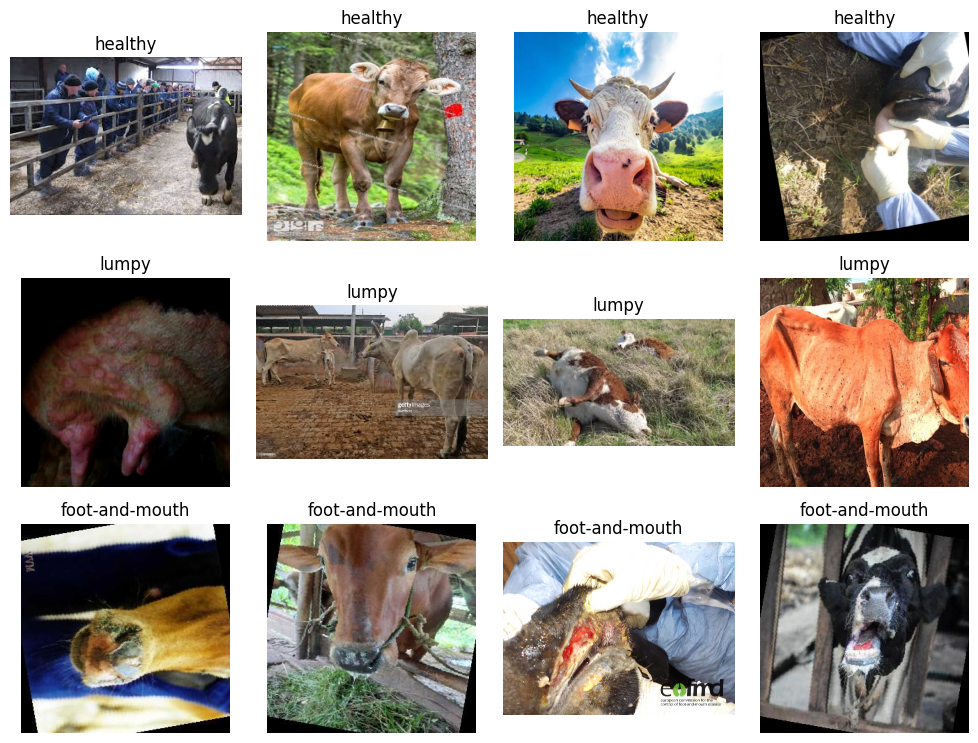

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,10))

for i,class_name in enumerate(EXPECTED_CLASSES):
  images=df[df["label"]==class_name]["filepath"].sample(4)
  for j,img_path in enumerate(images):
    image=Image.open(img_path)
    plt.subplot(4,4,i*4+j+1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(class_name)
    plt.tight_layout()
plt.show()

## **DIMENSIONS**

In [ ]:
sample_images=df.sample(10)
for image_path in sample_images["filepath"]:
  image=Image.open(image_path)
  print(os.path.basename(image_path),"-",image.size,"\n")

IMG_Lumpy_skin_disease_i_2_1_MAA9R3GQ_jpg.rf.1bd49d094107da006fd2911281a6f46a.jpg - (640, 640) 

imgs513.jpg - (262, 192) 

foot-and-mougth-2-_jpg.rf.ca32d38abd1e7a2dad291eb8ce8effef.jpg - (300, 300) 

moazx-316-_jpg.rf.03744004979fe1645b7f38bab64fc783.jpg - (300, 300) 

foot-and-mougth-13-_png_jpg.rf.a6fd06353c6acdb98cb9c9a5fdcddbaf.jpg - (300, 300) 

BrownSwisscattle20.jpg - (300, 300) 

Non-diseased-muzzle-28_jpg.rf.b011b1e484cbcda3c3c754f61a7343f8.jpg - (640, 640) 

Screenshot_2022_0901_184214_png_jpg.rf.ad0fa397ba58b65bacfb51f7216501ba.jpg - (640, 640) 

sapi_r_15.jpg - (753, 752) 

BrownSwisscattle105.jpg - (300, 300) 



## **TRAIN TEST VALIDATION SPLIT**

In [ ]:
from sklearn.model_selection import train_test_split

train_df,temp_df=train_test_split(df,test_size=0.3,stratify=df["label"],random_state=42)
val_df,test_df=train_test_split(temp_df,test_size=0.5,stratify=temp_df["label"],random_state=42)
print("train ",len(train_df))
print("val ",len(val_df))
print("test ",len(test_df))

train  2270
val  487
test  487


In [ ]:
print(train_df["label"].value_counts())
print(val_df["label"].value_counts())
print(test_df["label"].value_counts())

label
healthy           903
lumpy             845
foot-and-mouth    522
Name: count, dtype: int64
label
healthy           194
lumpy             181
foot-and-mouth    112
Name: count, dtype: int64
label
healthy           194
lumpy             181
foot-and-mouth    112
Name: count, dtype: int64


## **CLASS WEIGHTS FOR IMBALANCE**

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_names=EXPECTED_CLASSES
classindex={name: i for i,name in enumerate(class_names)}

y_train=train_df["label"].map(classindex).values

weights=compute_class_weight(class_weight="balanced",classes=np.arange(len(class_names)),y=y_train)

class_weights={i:weight for i,weight in enumerate(weights)}

print(class_names)
print(class_weights)

['healthy', 'lumpy', 'foot-and-mouth']
{0: np.float64(0.8379475821336286), 1: np.float64(0.8954635108481263), 2: np.float64(1.4495530012771392)}


## **IMG SETTINGS**

In [ ]:
IMG_SIZE=(224,224)
BATCH_SIZE=32
CHANNELS=3

## **IMG AUGMENTATION**

In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen=ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

## **VALIDATION & TEST PREPROCESSING**

In [ ]:
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

## **TRAIN IMAGE / VAL IMAGE / TEST IMAGE GENERATOR**

In [ ]:
train_generator=train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=class_names,
    shuffle=True,
    seed=42
)

Found 2270 validated image filenames belonging to 3 classes.


In [ ]:
val_generator=val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=class_names,
    shuffle=False,
)

Found 487 validated image filenames belonging to 3 classes.


In [ ]:
test_generator=test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=class_names,
    shuffle=False
)

Found 487 validated image filenames belonging to 3 classes.


## **EFFICIENTNET-B0**

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

base_model=EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)
base_model.trainable=False
print(len(base_model.layers))
print(base_model.trainable)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
238
False


## **CNN MODEL**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

In [ ]:
model=keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(128,activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(3,activation="softmax")
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,926 (16.07 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
callbacks=[keras.callbacks.ModelCheckpoint(
    'best_cattle_model.keras',monitor='val_loss',save_best_only=True,verbose=1
),
keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',factor=0.2,patience=2,min_lr=0.000001,verbose=1
)]

In [ ]:
EPOCHS=15
history=model.fit(
    train_generator,validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights,verbose=1
)


Epoch 1/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 750ms/step - accuracy: 0.7307 - loss: 0.6243
Epoch 1: val_loss improved from None to 0.34762, saving model to best_cattle_model.keras

Epoch 1: finished saving model to best_cattle_model.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.8115 - loss: 0.4577 - val_accuracy: 0.8747 - val_loss: 0.3476 - learning_rate: 0.0010
Epoch 2/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.8974 - loss: 0.2681
Epoch 2: val_loss improved from 0.34762 to 0.31783, saving model to best_cattle_model.keras

Epoch 2: finished saving model to best_cattle_model.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 38s 539ms/step - accuracy: 0.9013 - loss: 0.2588 - val_accuracy: 0.8994 - val_loss: 0.3178 - learning_rate: 0.0010
Epoch 3/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 508ms/step - accuracy: 0.9111 - loss: 0.2225
Epoch 3: val_loss did not improve from 0.31783
71/71 ━━━━━━━━━━━━━━━━━━━━ 38s 534ms/step - accuracy: 0.9115 - loss: 0.2286 - val_accuracy: 0.8768 - val_loss: 0.3

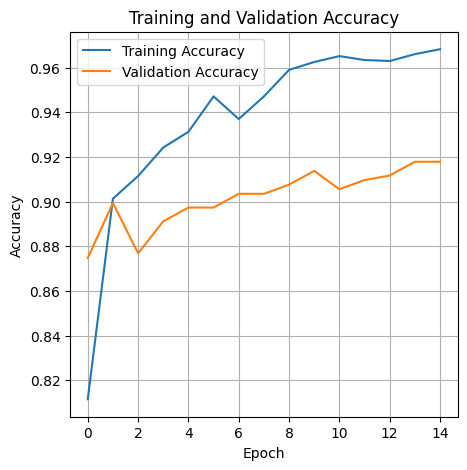

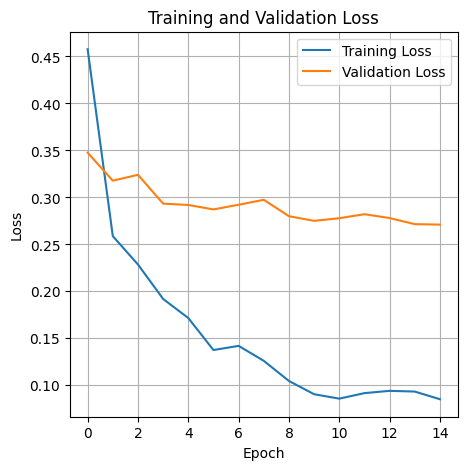

In [ ]:
plt.figure(figsize=(5, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()


# Plot loss
plt.figure(figsize=(5, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.9384 - loss: 0.1628
Test Loss: 0.16281554102897644
Test Accuracy: 0.9383983612060547


## **CLASSIFICATION REPORT**

In [ ]:
from sklearn.metrics import classification_report

test_generator.reset()
predictions= model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes=test_generator.classes


report = classification_report(true_classes, predicted_classes, target_names=class_names,digits=4)
print(report)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step
                precision    recall  f1-score   support

       healthy     0.9326    0.9278    0.9302       194
         lumpy     0.9489    0.9227    0.9356       181
foot-and-mouth     0.9322    0.9821    0.9565       112

      accuracy                         0.9384       487
     macro avg     0.9379    0.9442    0.9408       487
  weighted avg     0.9386    0.9384    0.9383       487



## **CONFUSION MATRIX**

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cmatrix=confusion_matrix(true_classes,predicted_classes)
cmatrix

array([[180,   8,   6],
       [ 12, 167,   2],
       [  1,   1, 110]])

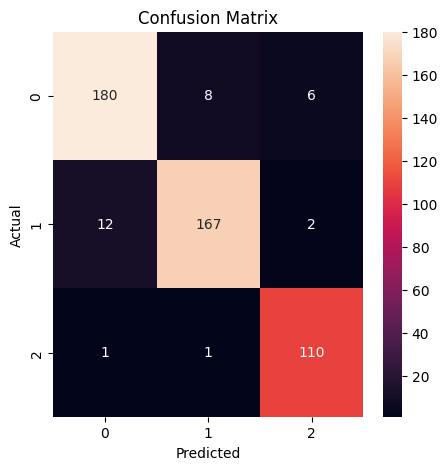

In [ ]:
plt.figure(figsize=(5,5))
sns.heatmap(cmatrix,annot=True,fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## **TESTING**

In [ ]:
image_path="/content/cowhealthy.webp"
if os.path.exists(image_path):
    print("Image found:", image_path)
else:
    print("Image not found. Check the filename.")

Image found: /content/cowhealthy.webp


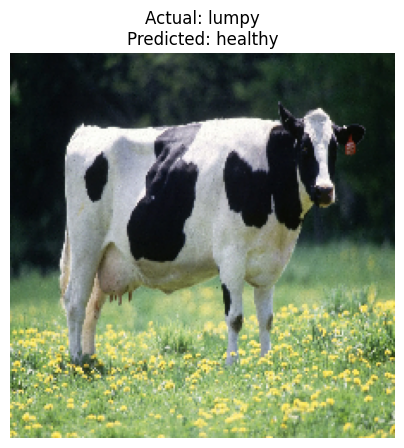

Actual Label    : lumpy
Predicted Label : healthy
Confidence      : 97.84%
Result          : INCORRECT ✗

Class Probabilities:
healthy        : 97.84%
lumpy          : 1.80%
foot-and-mouth : 0.36%


In [ ]:
# ============================================================
# STEP 30: TEST MODEL ON YOUR OWN IMAGE
# ============================================================

from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Enter the actual label of your image
# ------------------------------------------------------------
actual_label = "lumpy"


# ------------------------------------------------------------
# Load image
# ------------------------------------------------------------
image = load_img(image_path, target_size=IMG_SIZE)

# Convert image to array
image_array = img_to_array(image)

# Save a copy for displaying
display_image = image_array.astype("uint8")


# ------------------------------------------------------------
# Prepare image for the CNN
# ------------------------------------------------------------
# Add batch dimension:
# (224, 224, 3) → (1, 224, 224, 3)
input_image = np.expand_dims(image_array, axis=0)

# Apply the same preprocessing used during training
input_image = preprocess_input(input_image)


# ------------------------------------------------------------
# Make prediction
# ------------------------------------------------------------
probabilities = model.predict(input_image, verbose=0)[0]

predicted_index = np.argmax(probabilities)
predicted_label = class_names[predicted_index]
confidence = probabilities[predicted_index] * 100


# ------------------------------------------------------------
# Display image
# ------------------------------------------------------------
plt.figure(figsize=(5, 5))
plt.imshow(display_image)
plt.title(f"Actual: {actual_label}\nPredicted: {predicted_label}")
plt.axis("off")
plt.show()


# ------------------------------------------------------------
# Display prediction
# ------------------------------------------------------------
print("Actual Label    :", actual_label)
print("Predicted Label :", predicted_label)
print("Confidence      :", f"{confidence:.2f}%")

if predicted_label == actual_label:
    print("Result          : CORRECT ✓")
else:
    print("Result          : INCORRECT ✗")


# ------------------------------------------------------------
# Display all class probabilities
# ------------------------------------------------------------
print("\nClass Probabilities:")

for class_name, probability in zip(class_names, probabilities):
    print(f"{class_name:15s}: {probability * 100:.2f}%")

In [ ]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

image_path = "/content/cowhealthy.webp"
actual_label = "lumpy"

img = load_img(image_path, target_size=IMG_SIZE)
x = np.expand_dims(img_to_array(img), axis=0)
x = preprocess_input(x)

prob = model.predict(x, verbose=0)[0]
pred = class_names[np.argmax(prob)]

print("Actual    :", actual_label)
print("Predicted :", pred)
print("Confidence:", f"{max(prob)*100:.2f}%")

print("\nProbabilities:")
for c, p in zip(class_names, prob):
    print(f"{c}: {p*100:.2f}%")

Actual    : lumpy
Predicted : healthy
Confidence: 97.84%

Probabilities:
healthy: 97.84%
lumpy: 1.80%
foot-and-mouth: 0.36%


## **SAVE**

In [ ]:
import json
from google.colab import files

model.save("/content/cattle_disease_model.keras")

with open("/content/classes.json", "w") as f:
    json.dump(dict(enumerate(class_names)), f)

files.download("/content/cattle_disease_model.keras")
files.download("/content/classes.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("/content/cattle_disease_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>